In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
df = pd.read_csv('Travel.csv')
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


### Data Cleaning

#### Handling Missing Values

1. Handling missing values
2. Handling duplicates
3. Check data types
4. Understand the dataset

In [3]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [4]:
# Check all the categories

df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [5]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [6]:
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [7]:
df['Gender'] = df['Gender'].replace('Fe Male', 'Female')
df['MaritalStatus'] = df['MaritalStatus'].replace('Single', 'Unmarried')

In [8]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [9]:
# Check missing values
# these  are features with nan values
features_with_na = [features for features in df.columns if df[features].isnull().sum()>=1]
for feature in features_with_na:
    print(feature, np.round(df[feature].isnull().mean()*100,5), '% missing values')


Age 4.62357 % missing values
TypeofContact 0.51146 % missing values
DurationOfPitch 5.13502 % missing values
NumberOfFollowups 0.92062 % missing values
PreferredPropertyStar 0.53191 % missing values
NumberOfTrips 2.86416 % missing values
NumberOfChildrenVisiting 1.35025 % missing values
MonthlyIncome 4.76678 % missing values


In [10]:
# statistics on numerical columns (NULL cols)
df[features_with_na].select_dtypes(exclude = 'object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


#### Imputing Null Values

1. Median value for Age columns
2. Mode for TypeofContact
3. Median for DurationofPitch
4. Mode for NumberofFollwup as it is Discrete feature
5. Mode for PreferredPropertyStar
6. Median for NumberofTrips
7. Mode for NumberofChildrenVisiting
8. Median for MonthlyIncome

In [11]:
df.Age.fillna(df.Age.median(), inplace = True)

df.TypeofContact.fillna(df.TypeofContact.mode()[0], inplace = True)

df.DurationOfPitch.fillna(df.DurationOfPitch.median(), inplace = True)

df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0], inplace = True)

df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0], inplace = True)

df.NumberOfTrips.fillna(df.NumberOfTrips.median(), inplace = True)

df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0], inplace = True)

df.MonthlyIncome.fillna(df.MonthlyIncome.median(), inplace = True)

In [12]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [13]:
df.drop('CustomerID', inplace = True, axis = 1)

### Feature Engineering

Feature Extraction

In [14]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [15]:
df['TotalVisiting'] = df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']
df.drop(columns = ['NumberOfPersonVisiting', 'NumberOfChildrenVisiting'], axis = 1, inplace = True)

In [16]:
# get all numeric feature
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print('Number of numerical features :', len(num_features))

Number of numerical features : 12


In [17]:
# categoriacal features
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('Number of categorical features :', len(cat_features))

Number of categorical features : 6


In [18]:
# discrete features
discrete_features = [feature for feature in num_features if len(df[feature].unique())<=25]
print('Number of discrete features :', len(discrete_features))

Number of discrete features : 9


In [19]:
# continuous features
continuous_features = [feature for feature in num_features if feature not in discrete_features]
print('Number of continuous features :', len(continuous_features))

Number of continuous features : 3


### Train Test Split Model Training

In [20]:
from sklearn.model_selection import train_test_split
X = df.drop(['ProdTaken'], axis = 1)
y = df['ProdTaken']

In [21]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [22]:
X.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, X_test.shape

((3910, 17), (978, 17))

In [24]:
# Create columns Transformer with 3 types of transformers
cat_features = X.select_dtypes(include = 'object').columns
num_features = X.select_dtypes(exclude = 'object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop = 'first')

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)

In [25]:
preprocessor

,transformers,"[('OneHotEncoder', ...), ('StandardScaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,True


In [26]:
X_train = preprocessor.fit_transform(X_train)

In [27]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,0.679690,0.782966,-0.382245,-0.774151
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-0.721400,0.690023,0.282777,-0.725271,1.511598,-0.632399,0.679690,0.782966,-0.459799,0.643615
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.020350,0.282777,1.771041,0.418708,-0.632399,0.679690,0.782966,-0.245196,-0.065268
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,1.408395,-1.277194,0.213475,-0.065268
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,2.400396,-1.720227,-0.725271,1.511598,-0.632399,-0.049015,-1.277194,-0.024889,2.061382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3905,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-0.653841,1.284279,-0.725271,-0.674182,-0.632399,-1.506426,0.782966,-0.536973,0.643615
3906,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.455047,-0.898180,-0.718725,1.771041,-1.220627,-0.632399,1.408395,0.782966,1.529609,-0.065268
3907,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.455047,1.545210,0.282777,-0.725271,2.058043,-0.632399,-0.777720,0.782966,-0.360576,0.643615
3908,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.455047,1.789549,1.284279,-0.725271,-0.127737,-0.632399,-1.506426,0.782966,-0.252799,0.643615


In [28]:
X_test = preprocessor.transform(X_test)

In [29]:
pd.DataFrame(X_test)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.455047,-0.287333,1.284279,-0.725271,-1.220627,-0.632399,-0.777720,-1.277194,-0.737510,-0.774151
1,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.366823,-0.531672,0.282777,0.522885,-1.220627,1.581280,1.408395,-1.277194,-0.670411,-0.065268
2,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.455047,0.812193,0.282777,-0.725271,0.965153,-0.632399,1.408395,0.782966,-0.420832,-0.774151
3,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,-0.721400,2.522566,2.285781,-0.725271,1.511598,-0.632399,-0.049015,0.782966,-0.113658,0.643615
4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.455047,-1.020350,0.282777,0.522885,-0.127737,1.581280,0.679690,0.782966,-0.317047,2.061382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
973,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.721400,-1.020350,0.282777,-0.725271,1.511598,-0.632399,1.408395,0.782966,0.498219,0.643615
974,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.721400,-1.142519,0.282777,1.771041,-0.674182,1.581280,-1.506426,-1.277194,-1.184015,-1.483035
975,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-0.721400,1.056532,1.284279,-0.725271,-0.674182,1.581280,1.408395,0.782966,0.690012,0.643615
976,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-0.287333,-2.721728,-0.725271,-0.674182,-0.632399,1.408395,0.782966,-0.228278,-0.774151


In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, \
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [41]:
models = {
    "Decision Tree" : DecisionTreeClassifier(),
    "Logistic Regression" : LogisticRegression(),
    "Random Forest" : RandomForestClassifier(),
    "Gradient Boost": GradientBoostingClassifier(),
    "AdaBoost" : AdaBoostClassifier()
}
for i in range(len(list(models))):
    model  = list(models.values())[i]
    model.fit(X_train, y_train)

    # make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred, average = 'weighted')
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_roc_auc = roc_auc_score(y_train, y_train_pred)

    
    # Testing set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average = 'weighted')
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_roc_auc = roc_auc_score(y_test, y_test_pred)

    print(list(models.keys())[i])

    print('Model Performance for Training Set')
    print("-Accuracy: {:4f}". format(model_train_accuracy))
    print("-f1_score: {:4f}". format(model_train_f1))
    print("-precision_score: {:4f}". format(model_train_precision))
    print("-recall_score: {:4f}". format(model_train_recall))
    print("-roc_auc_score: {:4f}". format(model_train_roc_auc))


    print("--------------------------------------------")

    print('Model Performance for Testing Set')
    print("-Accuracy: {:4f}". format(model_test_accuracy))
    print("-f1_score: {:4f}". format(model_test_f1))
    print("-precision_score: {:4f}". format(model_test_precision))
    print("-recall_score: {:4f}". format(model_test_recall))
    print("-roc_auc_score: {:4f}". format(model_test_roc_auc))

    print('='*35)
    print('\n')

Decision Tree
Model Performance for Training Set
-Accuracy: 1.000000
-f1_score: 1.000000
-precision_score: 1.000000
-recall_score: 1.000000
-roc_auc_score: 1.000000
--------------------------------------------
Model Performance for Testing Set
-Accuracy: 0.919223
-f1_score: 0.918478
-precision_score: 0.807692
-recall_score: 0.769634
-roc_auc_score: 0.862580


Logistic Regression
Model Performance for Training Set
-Accuracy: 0.846036
-f1_score: 0.820212
-precision_score: 0.701587
-recall_score: 0.303155
-roc_auc_score: 0.636802
--------------------------------------------
Model Performance for Testing Set
-Accuracy: 0.836401
-f1_score: 0.808663
-precision_score: 0.691358
-recall_score: 0.293194
-roc_auc_score: 0.630714


Random Forest
Model Performance for Training Set
-Accuracy: 1.000000
-f1_score: 1.000000
-precision_score: 1.000000
-recall_score: 1.000000
-roc_auc_score: 1.000000
--------------------------------------------
Model Performance for Testing Set
-Accuracy: 0.932515
-f1_sc

### Hyperparameter Training

In [42]:
rf_params = {
    'max_depth': [5, 8, 15, None, 10],
    'max_features': [5, 7, 'auto', 8],
    'min_samples_split': [2, 8, 15,20],
    'n_estimators': [100, 200, 500, 1000] 
}

adaboost_params = {
    'n_estimators': [50, 60, 70, 80, 90],
    'algorithm': ['SAMME', 'SAMME.R']
}

In [43]:
adaboost_params

{'n_estimators': [50, 60, 70, 80, 90], 'algorithm': ['SAMME', 'SAMME.R']}

In [44]:
# Models list for hyperparameter tuning
randomcv_models = [
    ('RF', RandomForestClassifier(), rf_params),
    ('AB', AdaBoostClassifier(), adaboost_params)
]

In [45]:
randomcv_models

[('RF',
  RandomForestClassifier(),
  {'max_depth': [5, 8, 15, None, 10],
   'max_features': [5, 7, 'auto', 8],
   'min_samples_split': [2, 8, 15, 20],
   'n_estimators': [100, 200, 500, 1000]}),
 ('AB',
  AdaBoostClassifier(),
  {'n_estimators': [50, 60, 70, 80, 90], 'algorithm': ['SAMME', 'SAMME.R']})]

In [46]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator = model, 
                                param_distributions = params, 
                                n_iter = 100, 
                                cv = 3, 
                                verbose = 2, 
                                n_jobs = -1)
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"-------------- Best Params for {model_name} --------------")
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
-------------- Best Params for RF --------------
{'n_estimators': 500, 'min_samples_split': 2, 'max_features': 8, 'max_depth': None}
-------------- Best Params for AB --------------
{'n_estimators': 80, 'algorithm': 'SAMME'}


In [49]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators = 500, min_samples_split = 2, max_features = 8, max_depth = None),
    "AdaBoost": AdaBoostClassifier(n_estimators = 80, algorithm = 'SAMME')
}
for i in range(len(list(models))):
    model  = list(models.values())[i]
    model.fit(X_train, y_train)

    # make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred, average = 'weighted')
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_roc_auc = roc_auc_score(y_train, y_train_pred)

    
    # Testing set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average = 'weighted')
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_roc_auc = roc_auc_score(y_test, y_test_pred)

    print(list(models.keys())[i])

    print('Model Performance for Training Set')
    print("-Accuracy: {:4f}". format(model_train_accuracy))
    print("-f1_score: {:4f}". format(model_train_f1))
    print("-precision_score: {:4f}". format(model_train_precision))
    print("-recall_score: {:4f}". format(model_train_recall))
    print("-roc_auc_score: {:4f}". format(model_train_roc_auc))


    print("--------------------------------------------")

    print('Model Performance for Testing Set')
    print("-Accuracy: {:4f}". format(model_test_accuracy))
    print("-f1_score: {:4f}". format(model_test_f1))
    print("-precision_score: {:4f}". format(model_test_precision))
    print("-recall_score: {:4f}". format(model_test_recall))
    print("-roc_auc_score: {:4f}". format(model_test_roc_auc))

    print('='*35)
    print('\n')

Random Forest
Model Performance for Training Set
-Accuracy: 1.000000
-f1_score: 1.000000
-precision_score: 1.000000
-recall_score: 1.000000
-roc_auc_score: 1.000000
--------------------------------------------
Model Performance for Testing Set
-Accuracy: 0.935583
-f1_score: 0.931253
-precision_score: 0.970588
-recall_score: 0.691099
-roc_auc_score: 0.843008


AdaBoost
Model Performance for Training Set
-Accuracy: 0.846547
-f1_score: 0.813195
-precision_score: 0.769874
-recall_score: 0.252401
-roc_auc_score: 0.617555
--------------------------------------------
Model Performance for Testing Set
-Accuracy: 0.836401
-f1_score: 0.797684
-precision_score: 0.781818
-recall_score: 0.225131
-roc_auc_score: 0.604942




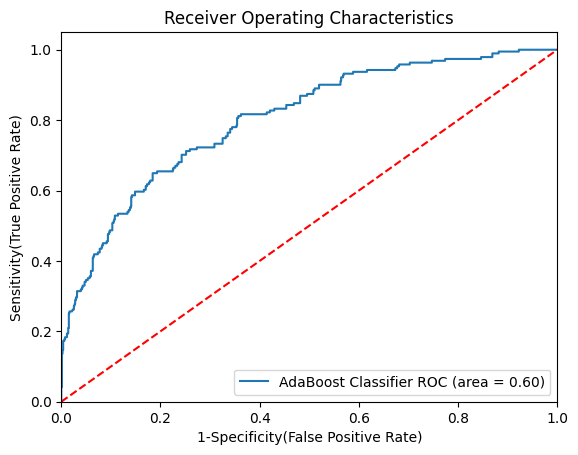

In [50]:
# Plot ROC AUC Curve
from sklearn.metrics import roc_auc_score, roc_curve
plt.figure()

# Add the models to the list that you want to view on the ROC plot
auc_models = [
    {
        'label': 'AdaBoost Classifier',
        'model': AdaBoostClassifier(n_estimators = 80, algorithm = 'SAMME'),
        'auc': 0.604942
    },
]
# create loop through all model
for algo in auc_models:
    model = algo['model']
    model.fit(X_train, y_train)
# Compute false positive and true positive rate
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
# Calculate area under the curve to display on the plot
    plt.plot(fpr, tpr, label = '%s ROC (area = %0.2f)' % (algo['label'], algo['auc']))
# Custom setting for plot
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("1-Specificity(False Positive Rate)")
plt.ylabel("Sensitivity(True Positive Rate)")
plt.title("Receiver Operating Characteristics")
plt.legend(loc = 'lower right')
plt.savefig("auc.png")
plt.show()